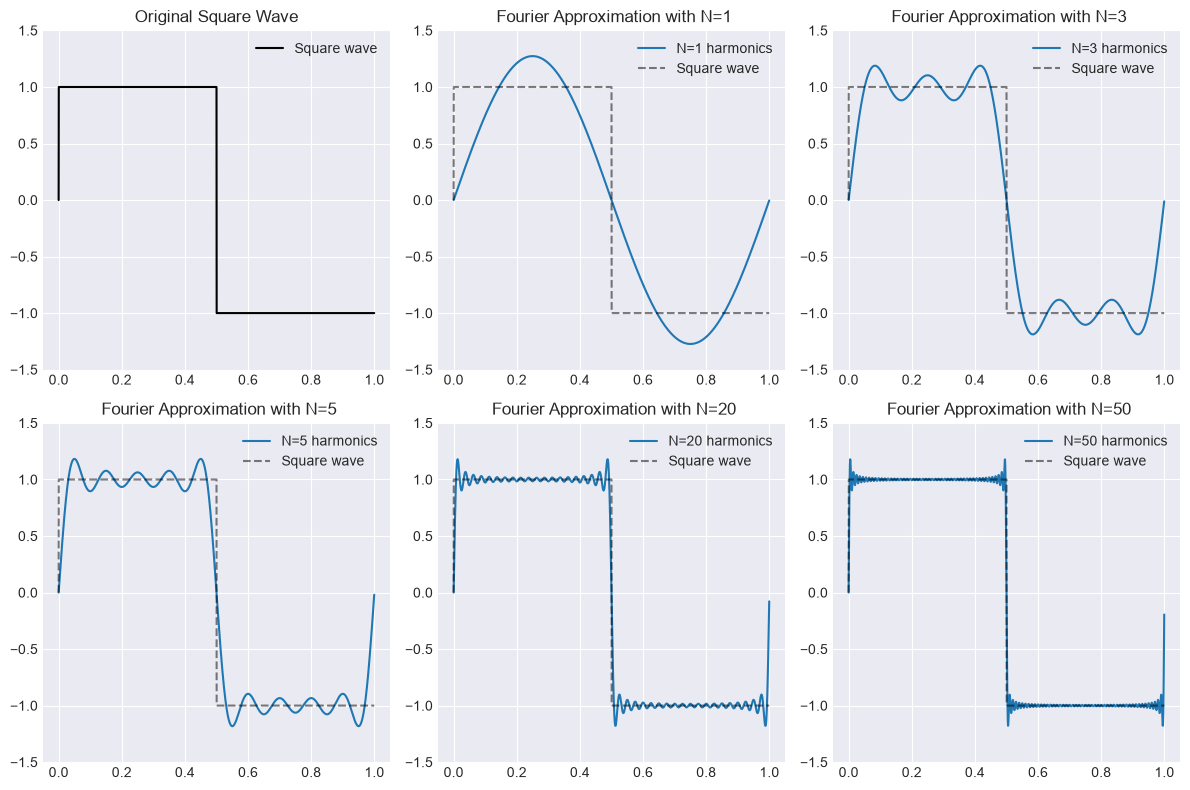

In [5]:
# 1.1
import numpy as np
import matplotlib . pyplot as plt
import time

# Set parameters for the signal
N = 2048    # Number of sample points
T = 1.0     # Duration of the signal in seconds
f0 = 1      # Fundamental frequency of the square wave in Hz

# List of harmonic numbers used to construct the square wave
harmonics = [1 , 3 , 5, 20, 50]

# Define the square wave function
def square_wave (t) :
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier (t, f0, N) :
    result = np.zeros_like(t)
    for k in range(N) :
        # The Fourier series of a square wave contains only odd harmonics .
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave .
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector
# np. linspace generates evenly spaced numbers over a specified interval .
# We use endpoint = False because the interval is periodic .
t = np.linspace(0.0, T, N, endpoint = False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize =(12 , 8))
# Plot the original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label ="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.legend()
# Plot Fourier reconstructions under different number of harmonics
for i , Nh in enumerate (harmonics, start = 2) :
    plt.subplot (2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label = f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha = 0.5, label ="Square wave")
    plt.title(f" Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()



--- Numpy DFT/FFT Performance Comparison ---
Naive DFT Execution Time: 4.352286 seconds
NumPy FFT Execution Time: 0.000000 seconds
Our DFT implementation is close to NumPy's FFT: True


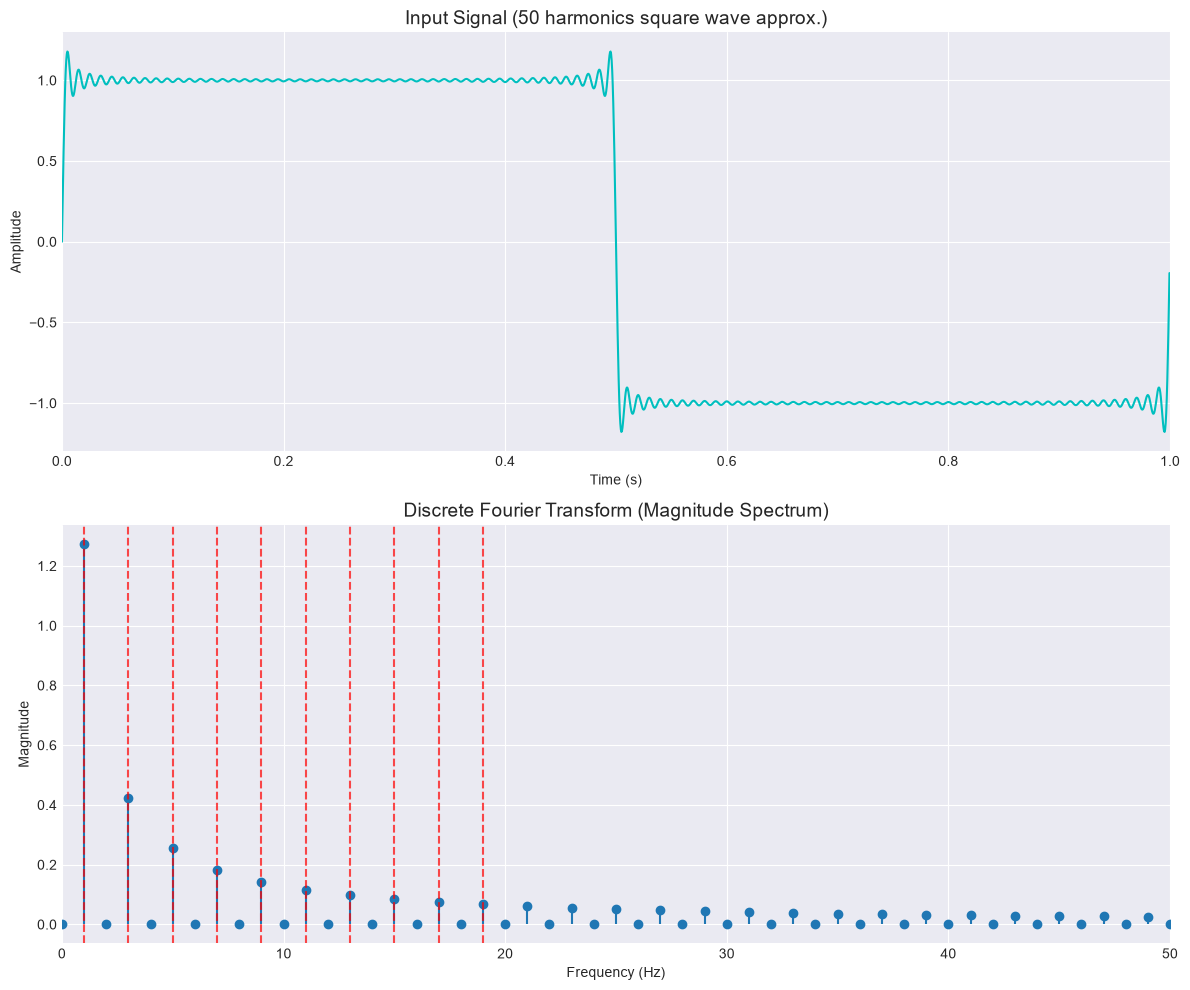

Saved: part1_dft_spectrum.png
Expect: peaks only at odd harmonics (1,3,5,7,9...), matching the odd-only
harmonics used to build the square wave. Even harmonics should be ~0.


In [ ]:
# 1.2
def naive_dft_numpy(x):
    N = len(x)
    X = np.zeros(N, dtype=np.complex128)
    for k in range(N):
        for n in range(N):
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X
 
signal_np = square_wave_fourier(t, f0, 50)
 
start_time_naive = time.time()
dft_result = naive_dft_numpy(signal_np)
naive_duration = time.time() - start_time_naive
 
start_time_fft = time.time()
fft_result = np.fft.fft(signal_np)
fft_duration = time.time() - start_time_fft
 
print("\n--- Numpy DFT/FFT Performance Comparison ---")
print(f"Naive DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")
if fft_duration > 0:
    print(f"FFT is approximately {naive_duration/fft_duration:.2f} times faster.")
print(f"Our DFT implementation is close to NumPy's FFT: {np.allclose(dft_result, fft_result)}")
 
xf = np.fft.fftfreq(N, d=T/N)[:N//2]
magnitude = 2.0/N * np.abs(dft_result[0:N//2])
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
ax1.plot(t, signal_np, color='c')
ax1.set_title('Input Signal (50 harmonics square wave approx.)', fontsize=14)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_xlim(0, 1.0)
ax1.grid(True)
 
ax2.stem(xf, magnitude, basefmt=" ")
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=14)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_xlim(0, 50)
ax2.grid(True)
for i in range(20):
    if i < len(xf) and i % 2 == 1:
        ax2.axvline(xf[i], color='r', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('part1_dft_spectrum.png', dpi=150)
plt.show()
print("Saved: part1_dft_spectrum.png")
print("Expect: peaks only at odd harmonics (1,3,5,7,9...), matching the odd-only")
print("harmonics used to build the square wave. Even harmonics should be ~0.")

Device: cpu


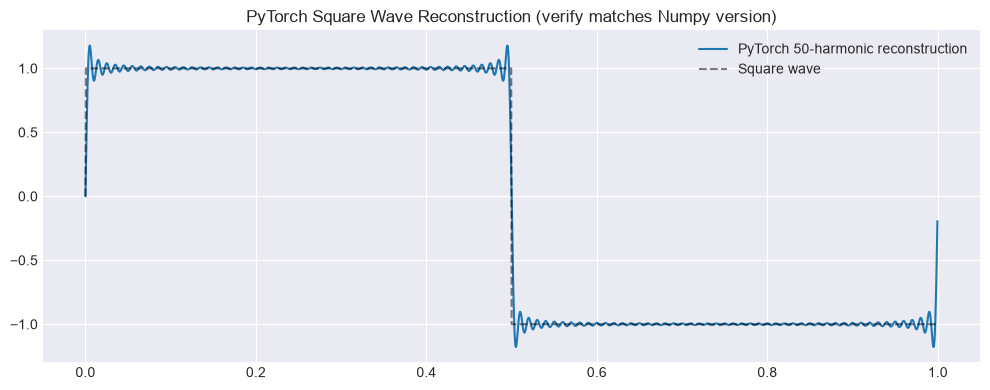

Saved: part1_pytorch_reconstruction.png
PyTorch reconstruction matches Numpy reconstruction: True


In [ ]:
# 1.3
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def square_wave_torch(t):
    return torch.sign(torch.sin(2.0 * np.pi * f0 * t))
 
def square_wave_fourier_torch(t, f0, N):
    result = torch.zeros_like(t)
    for k in range(N):
        n = 2 * k + 1
        result += torch.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result
 
def naive_dft_loop_torch(x):
    """Direct translation of the double-loop DFT formula -- slow, CPU only."""
    N = x.shape[0]
    X = torch.zeros(N, dtype=torch.complex128)
    for k in range(N):
        for n in range(N):
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X
 
def naive_dft_matrix_torch(x, device):
    """Vectorized: same O(N^2) formula written as one matrix multiply."""
    x = x.to(device)
    N = x.shape[0]
    n = torch.arange(N, device=device, dtype=torch.float64)
    k = n.reshape(-1, 1)
    angle = -2j * np.pi * k * n / N
    W = torch.exp(angle.to(torch.complex128)).to(device)
    return W @ x.to(torch.complex128)
 
# NOTE: torch.linspace always includes the final endpoint (no endpoint=False option
# like Numpy has), which silently gives a slightly different step size (T/(N-1)
# instead of T/N) and desyncs from the Numpy version above. Build the grid manually
# to exactly match np.linspace(0, T, N, endpoint=False):
t_torch = torch.arange(N, device=device, dtype=torch.float32) * (T / N)
square_torch = square_wave_torch(t_torch)
signal_torch = square_wave_fourier_torch(t_torch, f0, 50)
 
plt.figure(figsize=(10, 4))
plt.plot(t_torch.cpu().numpy(), signal_torch.cpu().numpy(), label="PyTorch 50-harmonic reconstruction")
plt.plot(t_torch.cpu().numpy(), square_torch.cpu().numpy(), 'k--', alpha=0.5, label="Square wave")
plt.title("PyTorch Square Wave Reconstruction (verify matches Numpy version)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('part1_pytorch_reconstruction.png', dpi=150)
plt.show()
print("Saved: part1_pytorch_reconstruction.png")
 
match = np.allclose(signal_torch.cpu().numpy(), signal_np, atol=1e-5)
print(f"PyTorch reconstruction matches Numpy reconstruction: {match}")


--- PyTorch DFT Timing Comparison (N=2048) ---
Naive DFT (Python double-loop, CPU): 113.518462s
Naive DFT (matrix multiply, cpu):    0.116081s
Built-in torch.fft.fft:              0.010013s
Loop vs matrix speedup: 977.9x
Matrix vs FFT speedup:  11.6x


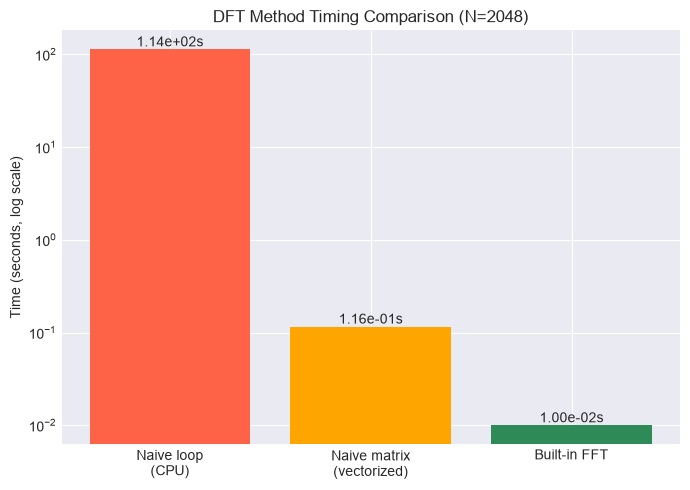

Saved: part1_timing_comparison.png


In [11]:
# 1.4
signal64 = signal_torch.to(torch.float64).cpu()
 
start = time.time()
X_loop = naive_dft_loop_torch(signal64)
t_loop = time.time() - start
 
start = time.time()
X_matrix = naive_dft_matrix_torch(signal64, device)
if device.type == 'cuda':
    torch.cuda.synchronize()
t_matrix = time.time() - start
 
start = time.time()
X_fft = torch.fft.fft(signal_torch.to(torch.complex128))
t_fft = time.time() - start
 
print("\n--- PyTorch DFT Timing Comparison (N=2048) ---")
print(f"Naive DFT (Python double-loop, CPU): {t_loop:.6f}s")
print(f"Naive DFT (matrix multiply, {device}):    {t_matrix:.6f}s")
print(f"Built-in torch.fft.fft:              {t_fft:.6f}s")
print(f"Loop vs matrix speedup: {t_loop/t_matrix:.1f}x")
print(f"Matrix vs FFT speedup:  {t_matrix/t_fft:.1f}x")
 
results = {
    "Naive loop\n(CPU)": t_loop,
    "Naive matrix\n(vectorized)": t_matrix,
    "Built-in FFT": t_fft,
}
plt.figure(figsize=(7, 5))
bars = plt.bar(results.keys(), results.values(), color=['tomato', 'orange', 'seagreen'])
plt.yscale('log')
plt.ylabel('Time (seconds, log scale)')
plt.title(f'DFT Method Timing Comparison (N={N})')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, val, f"{val:.2e}s", ha='center', va='bottom')
plt.tight_layout()
plt.savefig('part1_timing_comparison.png', dpi=150)
plt.show()
print("Saved: part1_timing_comparison.png")

N=  128 | loop=0.29440s | matrix=0.00100s | fft=0.000000s
N=  256 | loop=1.00301s | matrix=0.00200s | fft=0.000000s
N=  512 | loop=4.11650s | matrix=0.03550s | fft=0.000000s
N= 1024 | loop=23.08260s | matrix=0.03004s | fft=0.000998s
N= 2048 | loop=78.05632s | matrix=0.10851s | fft=0.001000s


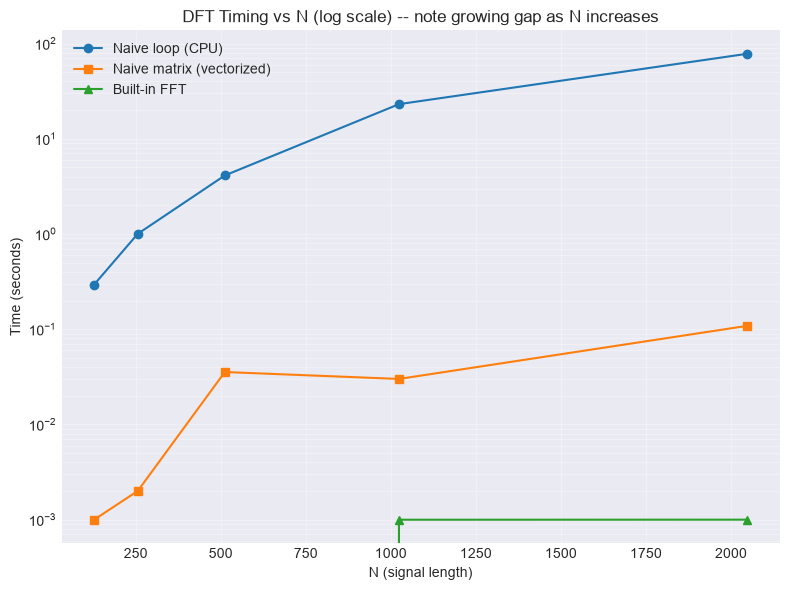

Saved: part1_timing_vs_n.png

Expected pattern: FFT (O(N log N)) grows slowly; both naive methods
(O(N^2)) grow much faster -- the gap should visibly widen as N increases.


In [13]:
Ns = [128, 256, 512, 1024, 2048]
timings_loop, timings_matrix, timings_fft = [], [], []
 
for Nval in Ns:
    tt = torch.arange(Nval, device=device, dtype=torch.float32) * (T / Nval)  # matches endpoint=False
    sig = square_wave_fourier_torch(tt, f0, 50).to(torch.float64).cpu()
 
    start = time.time()
    naive_dft_loop_torch(sig)
    timings_loop.append(time.time() - start)
 
    start = time.time()
    naive_dft_matrix_torch(sig, device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    timings_matrix.append(time.time() - start)
 
    start = time.time()
    torch.fft.fft(sig.to(torch.complex128))
    timings_fft.append(time.time() - start)
 
    print(f"N={Nval:5d} | loop={timings_loop[-1]:.5f}s | matrix={timings_matrix[-1]:.5f}s | fft={timings_fft[-1]:.6f}s")
 
plt.figure(figsize=(8, 6))
plt.plot(Ns, timings_loop, 'o-', label='Naive loop (CPU)')
plt.plot(Ns, timings_matrix, 's-', label='Naive matrix (vectorized)')
plt.plot(Ns, timings_fft, '^-', label='Built-in FFT')
plt.xlabel('N (signal length)')
plt.ylabel('Time (seconds)')
plt.yscale('log')
plt.title('DFT Timing vs N (log scale) -- note growing gap as N increases')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('part1_timing_vs_n.png', dpi=150)
plt.show()
print("Saved: part1_timing_vs_n.png")
print("\nExpected pattern: FFT (O(N log N)) grows slowly; both naive methods")
print("(O(N^2)) grow much faster -- the gap should visibly widen as N increases.")